
Scope: Deep temporal analysis for AQI forecasting readiness.
Covers trend decomposition, seasonality, stationarity, lag analysis,
autocorrelation, change point detection, rolling statistics, and
forecastability scoring — industry & research grade.

In [3]:
import json
import logging
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

In [4]:
# ── Paths ──────────────────────────────────────────────────────────
DATA_PATH = Path("../data/training/training_dataset.parquet")
FIGURES_DIR = Path("../reports/eda_timeseries/figures")
STATS_PATH = Path("../reports/eda_timeseries/timeseries_stats.json")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
STATS_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── Column Groups ──────────────────────────────────────────────────
POLLUTANT_COLS = ["pm25", "pm10", "no2", "so2", "co", "o3"]
WEATHER_COLS   = ["temperature", "feels_like", "humidity", "pressure", "visibility", "wind_speed", "cloudiness"]
TARGET_COL     = "aqi"
TIME_COL       = "timestamp"
CITY_COL       = "city"

# ── Stats Collector ──────────────────────────────────────────────
ts_stats = {}


In [5]:
df = pd.read_parquet(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

# Derive time features if not present
df["year"]         = df[TIME_COL].dt.year
df["month"]        = df[TIME_COL].dt.month
df["day"]          = df[TIME_COL].dt.day
df["hour"]         = df[TIME_COL].dt.hour
df["day_of_week"]  = df[TIME_COL].dt.dayofweek   # 0=Mon
df["is_weekend"]   = df["day_of_week"].isin([5, 6]).astype(int)

# Season mapping (South Asia)
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4]:
        return "Spring"
    elif month in [5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df[TIME_COL].min()} to {df[TIME_COL].max()}")
df.head()

Shape: 105054 rows, 33 columns
Date range: 2022-07-21 00:00:00+00:00 to 2026-07-18 23:00:00+00:00


,city,country,latitude,longitude,timestamp,temperature,feels_like,humidity,pressure,visibility,...,created_at,hour,day,month,day_of_week,is_weekend,aqi_change_rate,aqi_rolling_mean_3h,year,season
0,Islamabad,PK,33.6844,73.0479,2022-07-21 00:00:00+00:00,26.6,30.6,83,942,-1,...,2026-07-21T11:56:30.908001+00:00,0,21,7,3,0,0.0,0.0,2022,Monsoon
1,Islamabad,PK,33.6844,73.0479,2022-07-21 01:00:00+00:00,26.4,30.6,84,940,-1,...,2026-07-21T11:56:30.908001+00:00,1,21,7,3,0,0.0,0.0,2022,Monsoon
2,Islamabad,PK,33.6844,73.0479,2022-07-21 02:00:00+00:00,26.1,30.3,84,940,-1,...,2026-07-21T11:56:30.908001+00:00,2,21,7,3,0,0.0,0.0,2022,Monsoon
3,Islamabad,PK,33.6844,73.0479,2022-07-21 03:00:00+00:00,25.8,30.2,87,941,-1,...,2026-07-21T11:56:30.908001+00:00,3,21,7,3,0,0.0,0.0,2022,Monsoon
4,Islamabad,PK,33.6844,73.0479,2022-07-21 04:00:00+00:00,25.6,30.0,88,941,-1,...,2026-07-21T11:56:30.908001+00:00,4,21,7,3,0,0.0,0.0,2022,Monsoon


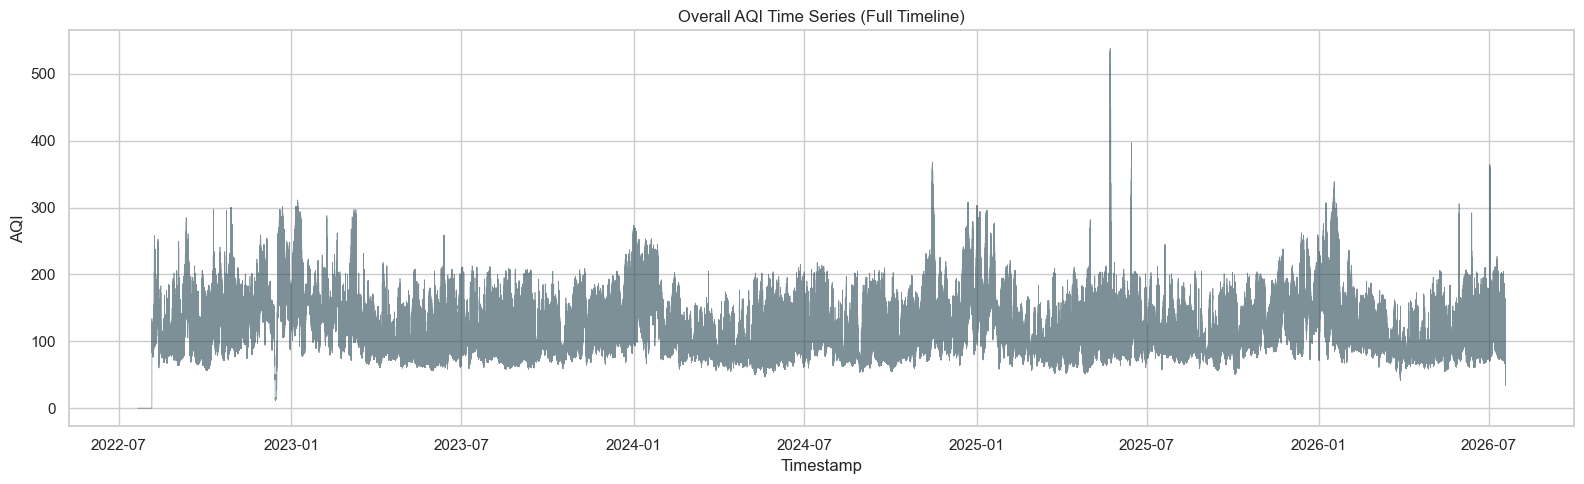

In [6]:
# Sort by time
df_sorted = df.sort_values(by=[TIME_COL])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_sorted[TIME_COL], df_sorted[TARGET_COL], color="#264653", alpha=0.6, linewidth=0.5)
ax.set_title("Overall AQI Time Series (Full Timeline)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("AQI")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "overall_aqi_timeseries.png", dpi=110, bbox_inches="tight")
plt.show()

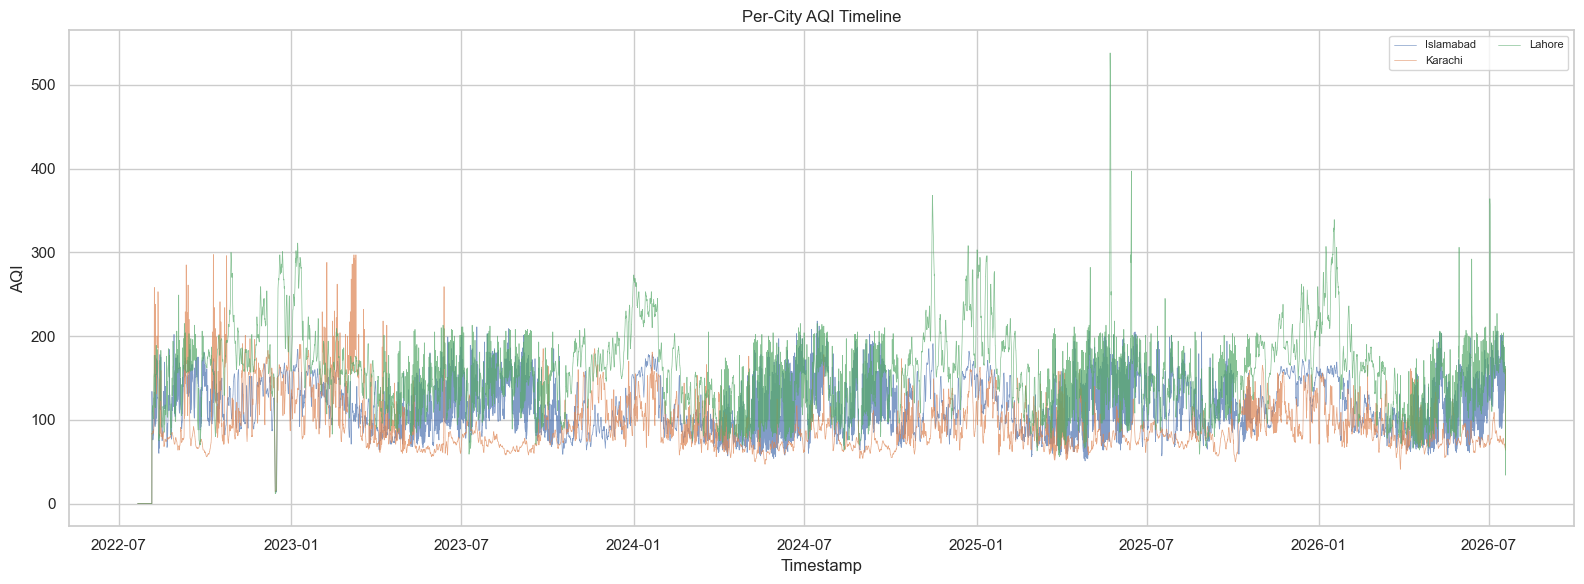

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))
for city, group in df_sorted.groupby(CITY_COL):
    ax.plot(group[TIME_COL], group[TARGET_COL], label=city, alpha=0.7, linewidth=0.5)
ax.set_title("Per-City AQI Timeline")
ax.set_xlabel("Timestamp")
ax.set_ylabel("AQI")
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "per_city_aqi_timeline.png", dpi=110, bbox_inches="tight")
plt.show()

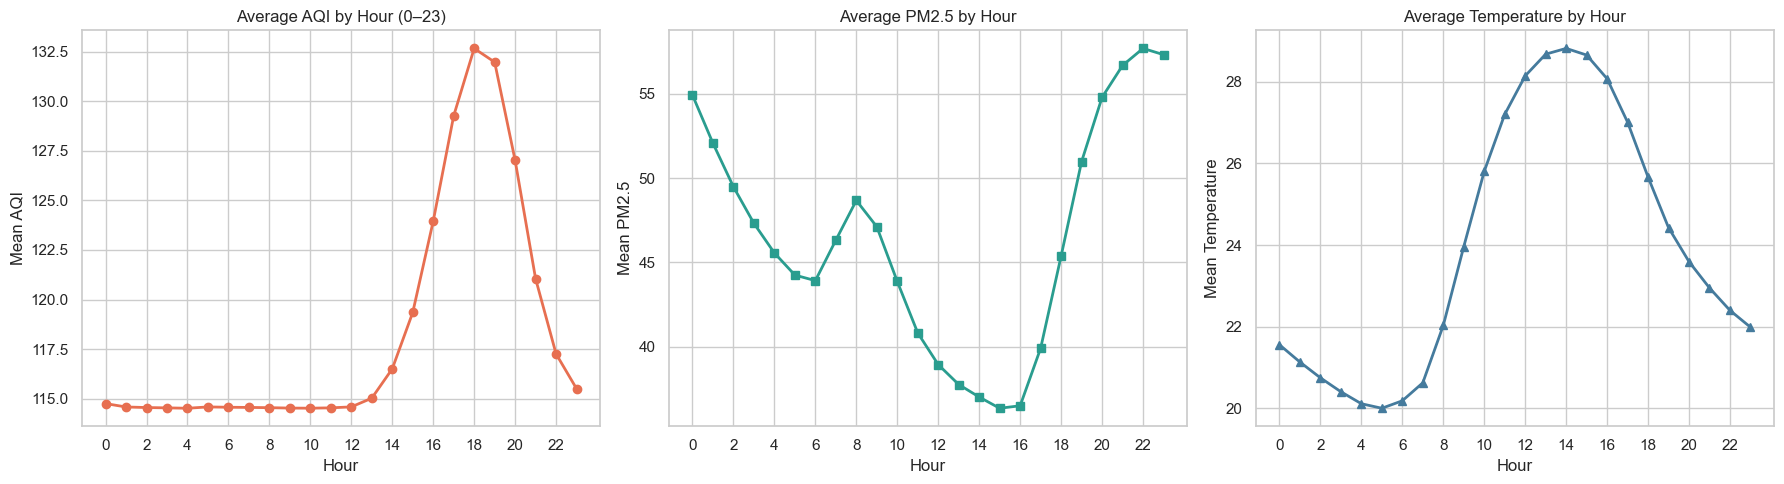

In [8]:
hourly_patterns = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AQI by hour
hourly_aqi = df.groupby("hour")[TARGET_COL].mean()
hourly_patterns["aqi"] = hourly_aqi.round(2).to_dict()
axes[0].plot(hourly_aqi.index, hourly_aqi.values, marker="o", color="#e76f51", linewidth=2)
axes[0].set_title("Average AQI by Hour (0–23)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean AQI")
axes[0].set_xticks(range(0, 24, 2))

# PM2.5 by hour
if "pm25" in df.columns:
    hourly_pm25 = df.groupby("hour")["pm25"].mean()
    hourly_patterns["pm25"] = hourly_pm25.round(2).to_dict()
    axes[1].plot(hourly_pm25.index, hourly_pm25.values, marker="s", color="#2a9d8f", linewidth=2)
    axes[1].set_title("Average PM2.5 by Hour")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean PM2.5")
    axes[1].set_xticks(range(0, 24, 2))

# Temperature by hour
if "temperature" in df.columns:
    hourly_temp = df.groupby("hour")["temperature"].mean()
    hourly_patterns["temperature"] = hourly_temp.round(2).to_dict()
    axes[2].plot(hourly_temp.index, hourly_temp.values, marker="^", color="#457b9d", linewidth=2)
    axes[2].set_title("Average Temperature by Hour")
    axes[2].set_xlabel("Hour")
    axes[2].set_ylabel("Mean Temperature")
    axes[2].set_xticks(range(0, 24, 2))

ts_stats["hourly_patterns"] = hourly_patterns
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hourly_pattern_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

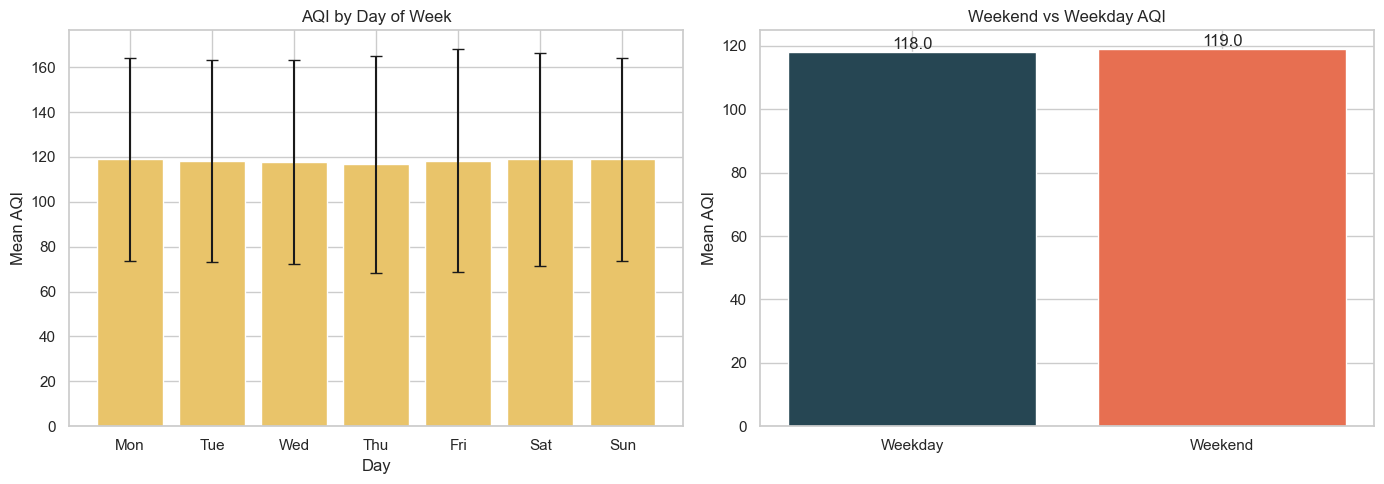

,mean,std,count
Weekday,118.02,46.76,75024
Weekend,118.97,46.34,30030


In [9]:
dow_aqi = df.groupby("day_of_week")[TARGET_COL].agg(["mean", "std"]).round(2)
weekend_vs_weekday = df.groupby("is_weekend")[TARGET_COL].agg(["mean", "std", "count"]).round(2)
weekend_vs_weekday.index = ["Weekday", "Weekend"]

ts_stats["daily_patterns"] = {
    "day_of_week": dow_aqi.to_dict(orient="index"),
    "weekend_vs_weekday": weekend_vs_weekday.to_dict(orient="index"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[0].bar(range(7), dow_aqi["mean"], color="#e9c46a", yerr=dow_aqi["std"], capsize=4)
axes[0].set_title("AQI by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Mean AQI")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels)

# Weekend vs Weekday
axes[1].bar(weekend_vs_weekday.index, weekend_vs_weekday["mean"], color=["#264653", "#e76f51"])
axes[1].set_title("Weekend vs Weekday AQI")
axes[1].set_ylabel("Mean AQI")
for i, v in enumerate(weekend_vs_weekday["mean"]):
    axes[1].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=12)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "daily_pattern_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

weekend_vs_weekday

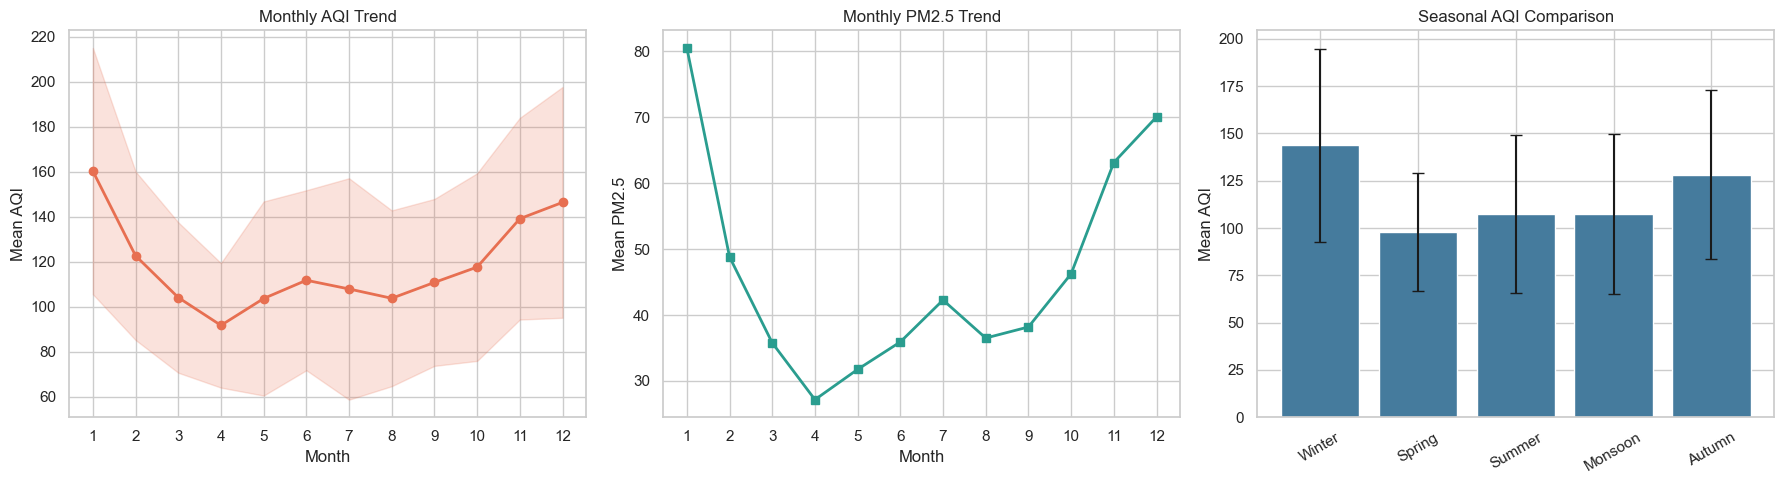

,mean,std,count
season,,,
Winter,143.68,51.05,25992
Spring,97.95,31.35,17568
Summer,107.58,41.83,17568
Monsoon,107.39,42.24,26358
Autumn,128.14,44.58,17568


In [10]:
monthly_aqi = df.groupby("month")[TARGET_COL].agg(["mean", "std"]).round(2)
monthly_pm25 = df.groupby("month")["pm25"].mean().round(2) if "pm25" in df.columns else None
seasonal_aqi = df.groupby("season")[TARGET_COL].agg(["mean", "std", "count"]).round(2)

ts_stats["monthly_seasonal"] = {
    "monthly_aqi": monthly_aqi.to_dict(orient="index"),
    "seasonal_aqi": seasonal_aqi.to_dict(orient="index"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly AQI
axes[0].plot(monthly_aqi.index, monthly_aqi["mean"], marker="o", color="#e76f51", linewidth=2)
axes[0].fill_between(monthly_aqi.index,
                     monthly_aqi["mean"] - monthly_aqi["std"],
                     monthly_aqi["mean"] + monthly_aqi["std"],
                     alpha=0.2, color="#e76f51")
axes[0].set_title("Monthly AQI Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean AQI")
axes[0].set_xticks(range(1, 13))

# Monthly PM2.5
if monthly_pm25 is not None:
    axes[1].plot(monthly_pm25.index, monthly_pm25.values, marker="s", color="#2a9d8f", linewidth=2)
    axes[1].set_title("Monthly PM2.5 Trend")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Mean PM2.5")
    axes[1].set_xticks(range(1, 13))

# Seasonal comparison
season_order = ["Winter", "Spring", "Summer", "Monsoon", "Autumn"]
seasonal_aqi = seasonal_aqi.reindex([s for s in season_order if s in seasonal_aqi.index])
axes[2].bar(seasonal_aqi.index, seasonal_aqi["mean"], color="#457b9d",
            yerr=seasonal_aqi["std"], capsize=4)
axes[2].set_title("Seasonal AQI Comparison")
axes[2].set_ylabel("Mean AQI")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_seasonal_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

seasonal_aqi

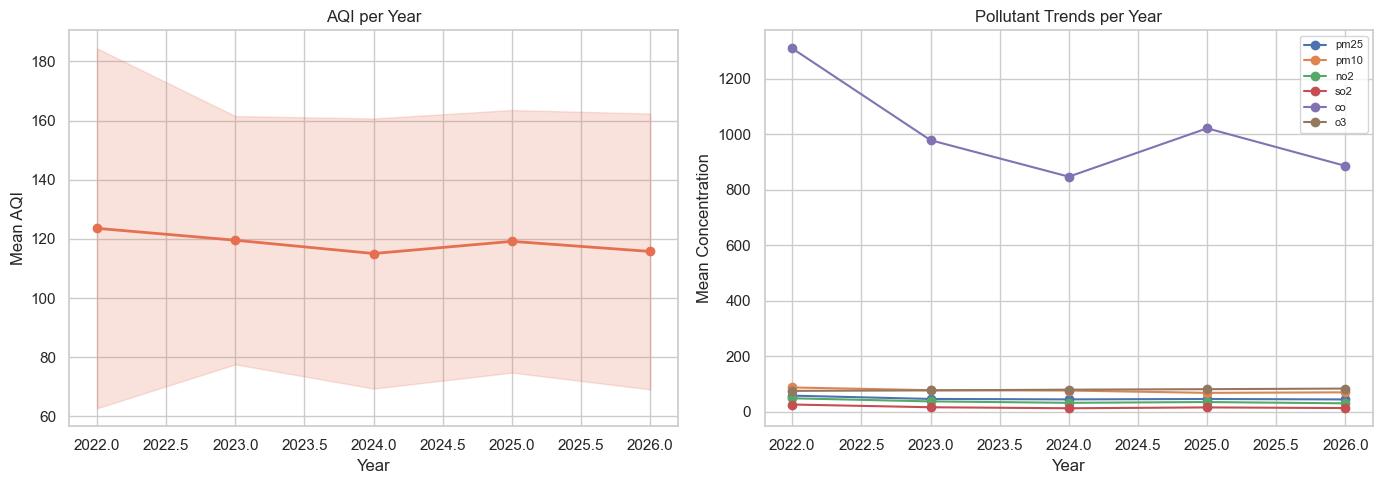

,mean,std,count
year,,,
2022,123.60,60.82,11808
2023,119.58,41.96,26280
2024,115.08,45.65,26352
2025,119.20,44.38,26280
2026,115.78,46.61,14334


In [11]:
yearly_aqi = df.groupby("year")[TARGET_COL].agg(["mean", "std", "count"]).round(2)

available_pollutants = [c for c in POLLUTANT_COLS if c in df.columns]
yearly_pollutants = df.groupby("year")[available_pollutants].mean().round(2)

ts_stats["yearly_trends"] = {
    "aqi": yearly_aqi.to_dict(orient="index"),
    "pollutants": yearly_pollutants.to_dict(orient="index"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly AQI
axes[0].plot(yearly_aqi.index, yearly_aqi["mean"], marker="o", color="#e76f51", linewidth=2)
axes[0].fill_between(yearly_aqi.index,
                     yearly_aqi["mean"] - yearly_aqi["std"],
                     yearly_aqi["mean"] + yearly_aqi["std"],
                     alpha=0.2, color="#e76f51")
axes[0].set_title("AQI per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean AQI")

# Yearly pollutant trends
for col in available_pollutants:
    axes[1].plot(yearly_pollutants.index, yearly_pollutants[col], marker="o", label=col, linewidth=1.5)
axes[1].set_title("Pollutant Trends per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Concentration")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "yearly_trend_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

yearly_aqi

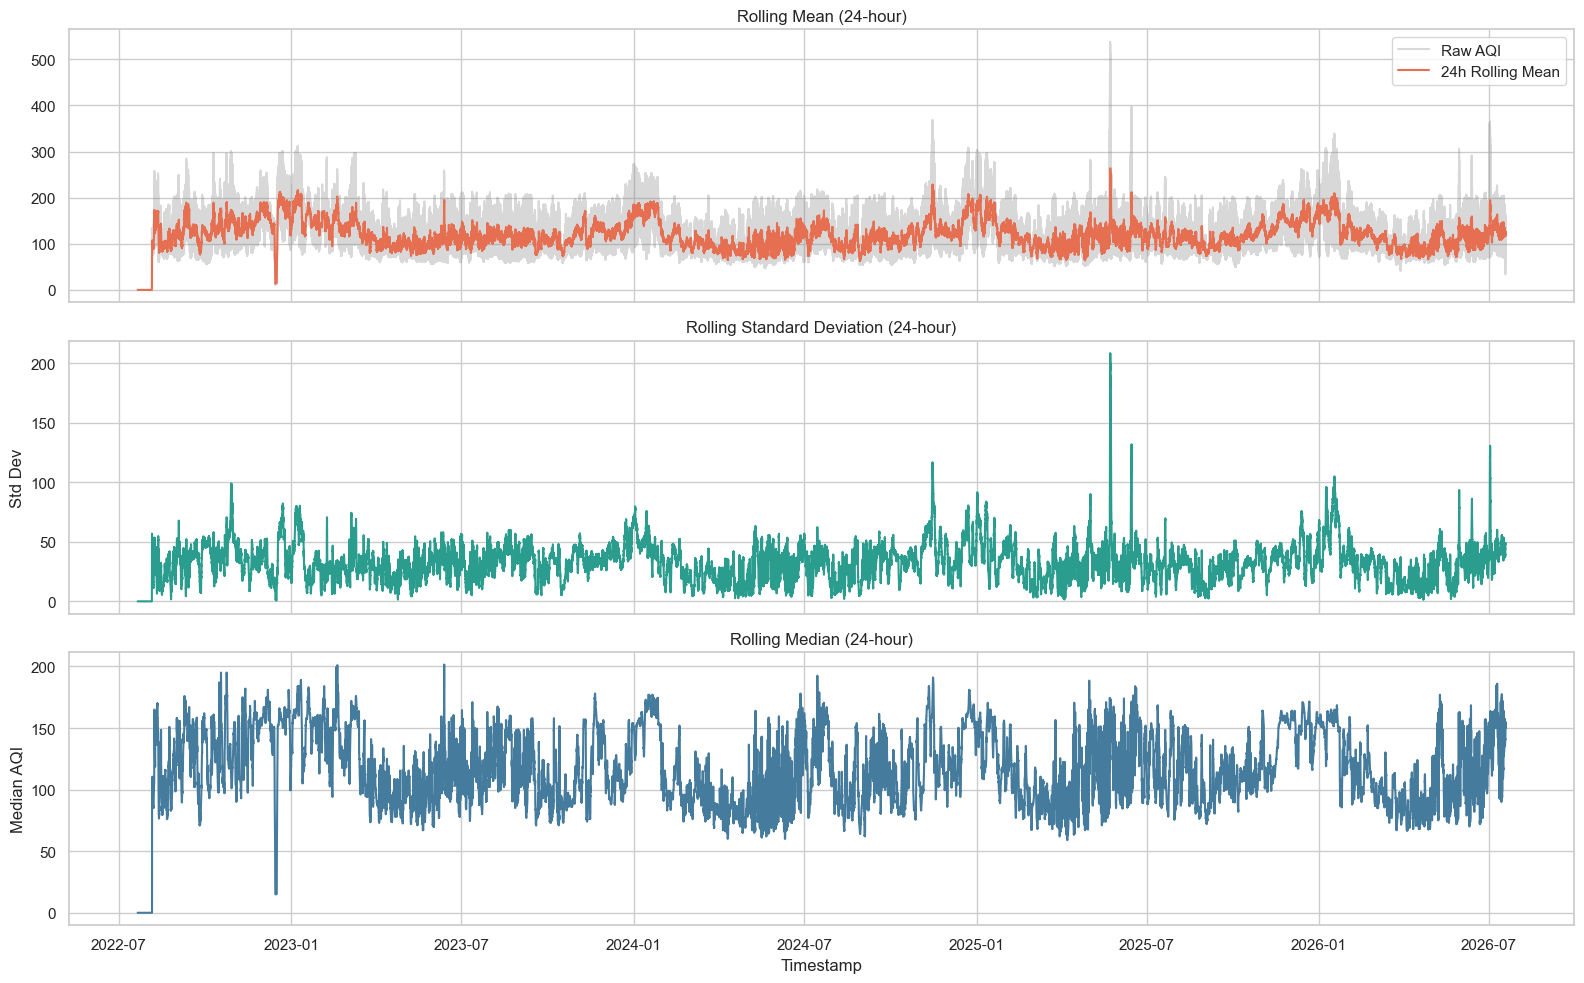

In [12]:
# Focus on overall AQI series (sorted)
aqi_series = df_sorted.set_index(TIME_COL)[TARGET_COL].sort_index()

rolling_mean_24h   = aqi_series.rolling(window=24, min_periods=1).mean()
rolling_std_24h    = aqi_series.rolling(window=24, min_periods=1).std()
rolling_median_24h = aqi_series.rolling(window=24, min_periods=1).median()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(aqi_series.index, aqi_series.values, alpha=0.3, color="gray", label="Raw AQI")
axes[0].plot(rolling_mean_24h.index, rolling_mean_24h.values, color="#e76f51", label="24h Rolling Mean", linewidth=1.5)
axes[0].set_title("Rolling Mean (24-hour)")
axes[0].legend()

axes[1].plot(rolling_std_24h.index, rolling_std_24h.values, color="#2a9d8f", linewidth=1.5)
axes[1].set_title("Rolling Standard Deviation (24-hour)")
axes[1].set_ylabel("Std Dev")

axes[2].plot(rolling_median_24h.index, rolling_median_24h.values, color="#457b9d", linewidth=1.5)
axes[2].set_title("Rolling Median (24-hour)")
axes[2].set_ylabel("Median AQI")
axes[2].set_xlabel("Timestamp")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "rolling_statistics_24h.png", dpi=110, bbox_inches="tight")
plt.show()

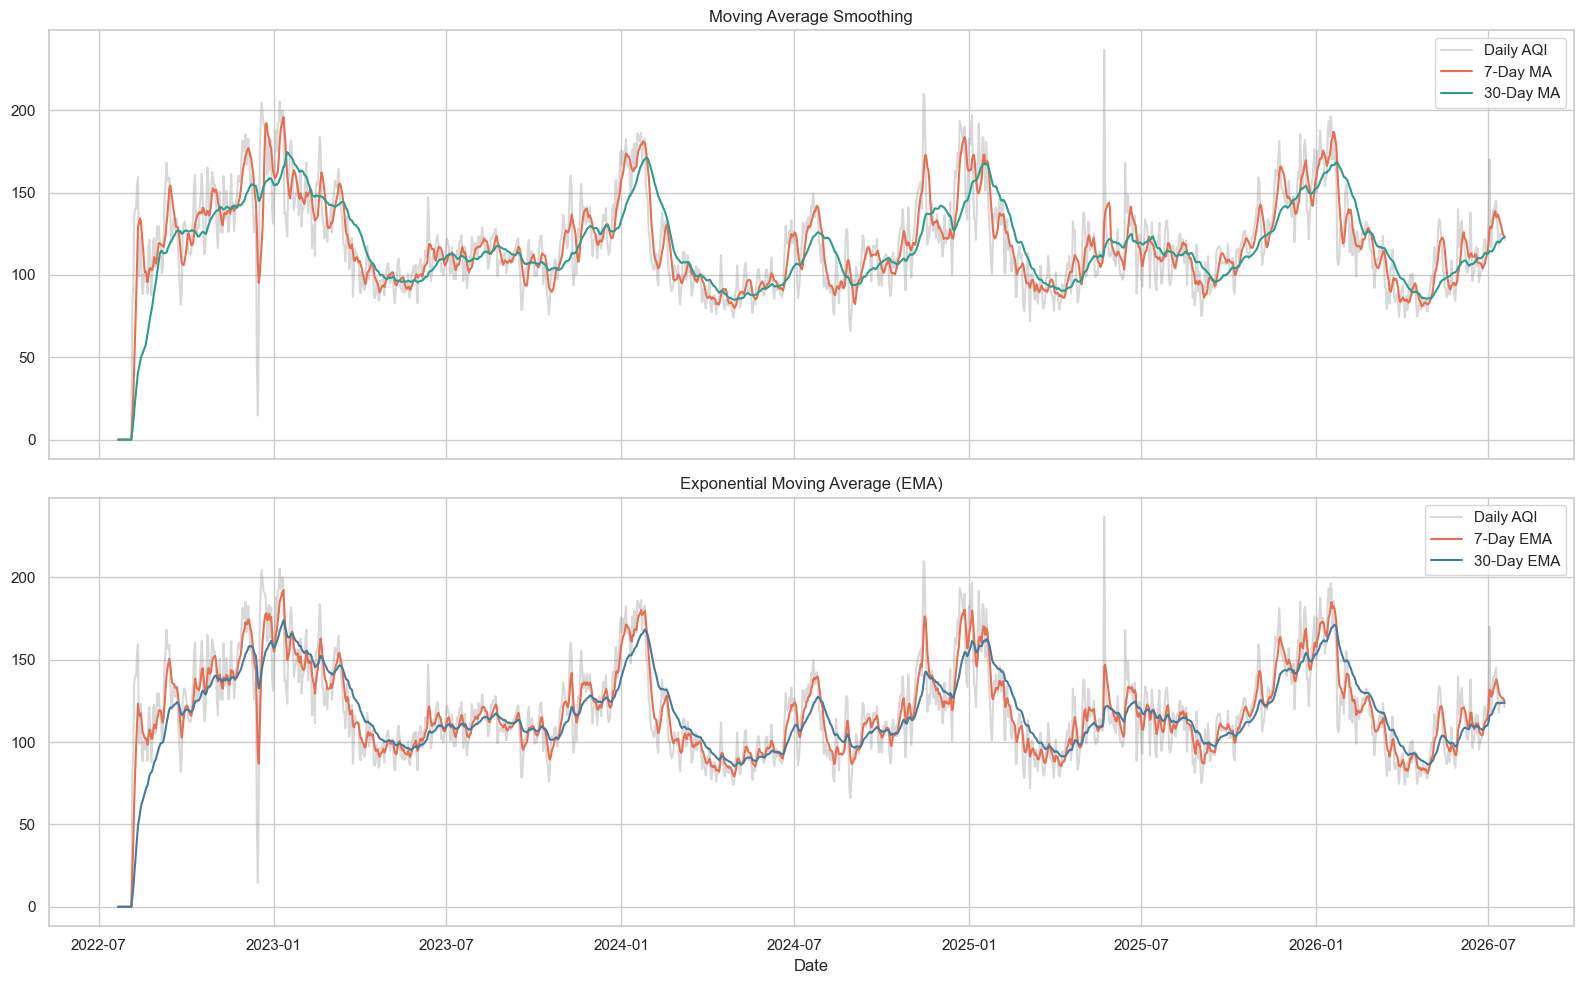

In [13]:
# Resample to hourly if needed, or use existing
daily_aqi = aqi_series.resample("1D").mean().dropna()

# Moving Averages
ma_7  = daily_aqi.rolling(window=7, min_periods=1).mean()
ma_30 = daily_aqi.rolling(window=30, min_periods=1).mean()

# Exponential Moving Average
ema_7  = daily_aqi.ewm(span=7, adjust=False).mean()
ema_30 = daily_aqi.ewm(span=30, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Moving Average
axes[0].plot(daily_aqi.index, daily_aqi.values, alpha=0.3, color="gray", label="Daily AQI")
axes[0].plot(ma_7.index, ma_7.values, color="#e76f51", label="7-Day MA", linewidth=1.5)
axes[0].plot(ma_30.index, ma_30.values, color="#2a9d8f", label="30-Day MA", linewidth=1.5)
axes[0].set_title("Moving Average Smoothing")
axes[0].legend()

# EMA
axes[1].plot(daily_aqi.index, daily_aqi.values, alpha=0.3, color="gray", label="Daily AQI")
axes[1].plot(ema_7.index, ema_7.values, color="#e76f51", label="7-Day EMA", linewidth=1.5)
axes[1].plot(ema_30.index, ema_30.values, color="#457b9d", label="30-Day EMA", linewidth=1.5)
axes[1].set_title("Exponential Moving Average (EMA)")
axes[1].set_xlabel("Date")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "trend_smoothing_ma_ema.png", dpi=110, bbox_inches="tight")
plt.show()

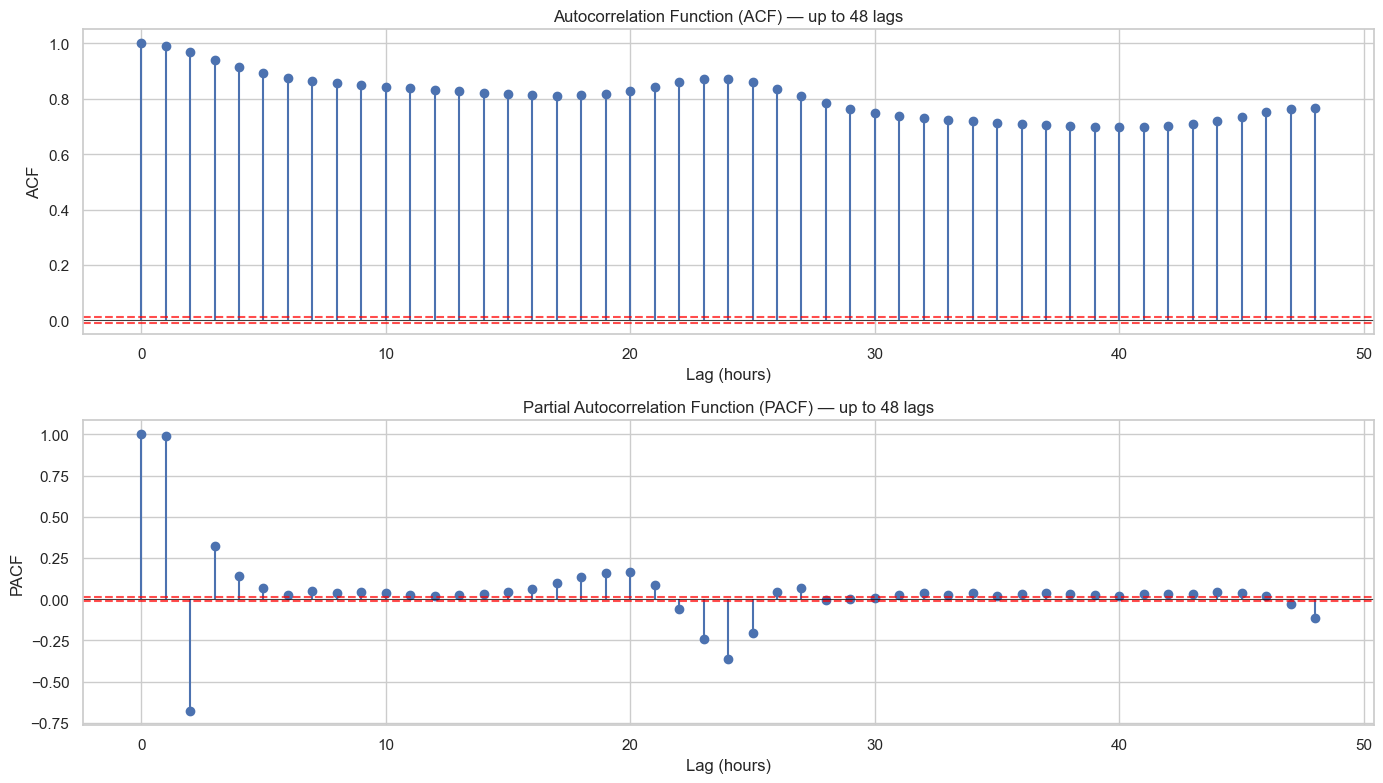

In [14]:
# Use a clean hourly series (no NaNs)
hourly_aqi_series = aqi_series.resample("1H").mean().interpolate(method="linear").dropna()

max_lags = min(48, len(hourly_aqi_series) // 2 - 1)

# ACF
acf_vals, acf_conf = acf(hourly_aqi_series, nlags=max_lags, alpha=0.05)
# PACF
pacf_vals, pacf_conf = pacf(hourly_aqi_series, nlags=max_lags, alpha=0.05)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF Plot
axes[0].stem(range(len(acf_vals)), acf_vals, basefmt=" ")
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].axhline(y=1.96/np.sqrt(len(hourly_aqi_series)), color="red", linestyle="--", alpha=0.7)
axes[0].axhline(y=-1.96/np.sqrt(len(hourly_aqi_series)), color="red", linestyle="--", alpha=0.7)
axes[0].set_title(f"Autocorrelation Function (ACF) — up to {max_lags} lags")
axes[0].set_xlabel("Lag (hours)")
axes[0].set_ylabel("ACF")

# PACF Plot
axes[1].stem(range(len(pacf_vals)), pacf_vals, basefmt=" ")
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].axhline(y=1.96/np.sqrt(len(hourly_aqi_series)), color="red", linestyle="--", alpha=0.7)
axes[1].axhline(y=-1.96/np.sqrt(len(hourly_aqi_series)), color="red", linestyle="--", alpha=0.7)
axes[1].set_title(f"Partial Autocorrelation Function (PACF) — up to {max_lags} lags")
axes[1].set_xlabel("Lag (hours)")
axes[1].set_ylabel("PACF")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "autocorrelation_acf_pacf.png", dpi=110, bbox_inches="tight")
plt.show()

ts_stats["autocorrelation"] = {
    "max_lags": max_lags,
    "acf_significant_lags": [i for i, v in enumerate(acf_vals) if abs(v) > 1.96/np.sqrt(len(hourly_aqi_series)) and i > 0],
    "pacf_significant_lags": [i for i, v in enumerate(pacf_vals) if abs(v) > 1.96/np.sqrt(len(hourly_aqi_series)) and i > 0],
}

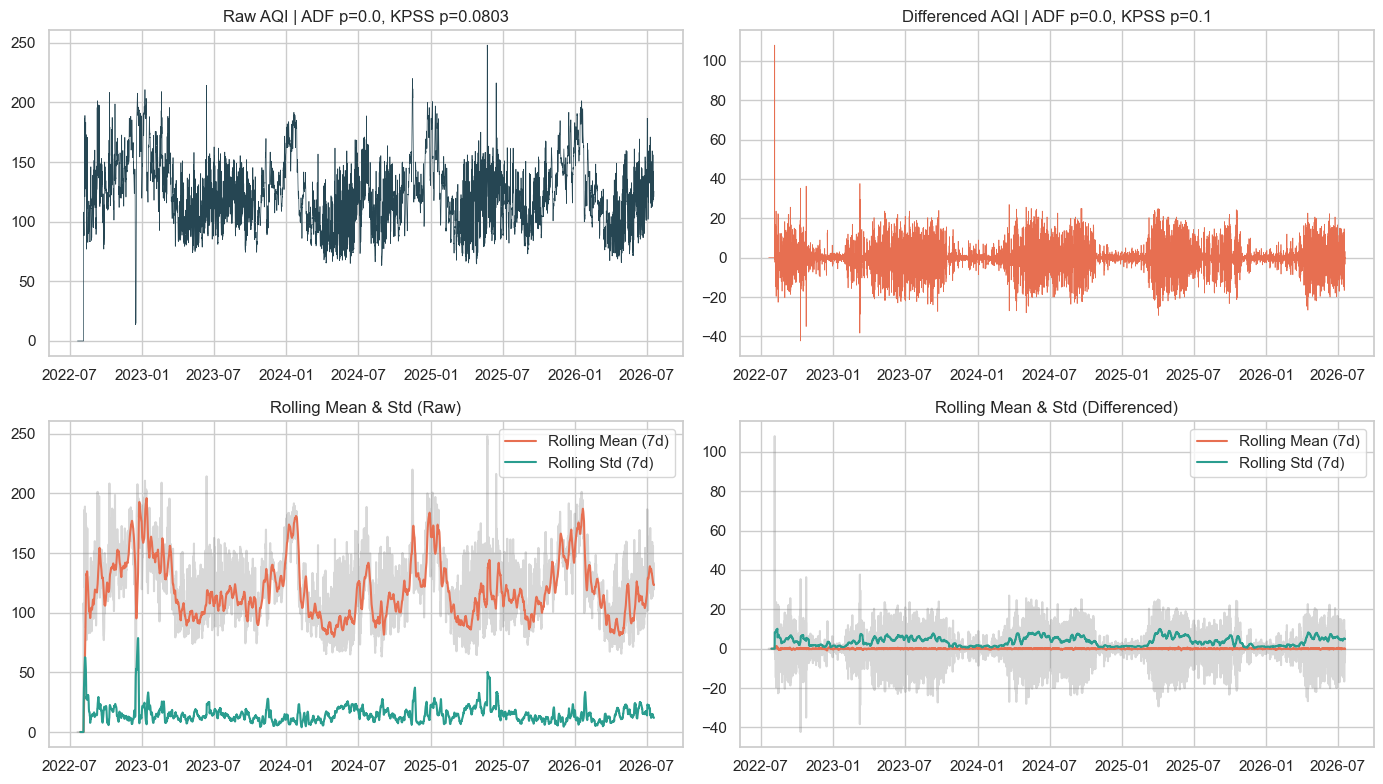

=== Stationarity Results ===
Raw   — ADF p=0.0 (stationary=True), KPSS p=0.0803 (stationary=True)
Diff  — ADF p=0.0 (stationary=True), KPSS p=0.1 (stationary=True)


In [15]:
def adf_test(series, name="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "test": "ADF",
        "statistic": round(result[0], 4),
        "p_value": round(result[1], 4),
        "critical_values": {k: round(v, 4) for k, v in result[4].items()},
        "is_stationary": result[1] < 0.05,
    }

def kpss_test(series, name="Series"):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "test": "KPSS",
        "statistic": round(result[0], 4),
        "p_value": round(result[1], 4),
        "critical_values": {k: round(v, 4) for k, v in result[3].items()},
        "is_stationary": result[1] > 0.05,
    }

# Test on raw series
adf_raw = adf_test(hourly_aqi_series, "AQI Raw")
kpss_raw = kpss_test(hourly_aqi_series, "AQI Raw")

# Test on differenced series (1st order)
hourly_aqi_diff = hourly_aqi_series.diff().dropna()
adf_diff = adf_test(hourly_aqi_diff, "AQI Diff(1)")
kpss_diff = kpss_test(hourly_aqi_diff, "AQI Diff(1)")

stationarity_results = {
    "raw_series": {"adf": adf_raw, "kpss": kpss_raw},
    "differenced_series": {"adf": adf_diff, "kpss": kpss_diff},
}
ts_stats["stationarity_tests"] = stationarity_results

# Visual summary
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(hourly_aqi_series.index, hourly_aqi_series.values, color="#264653", linewidth=0.5)
axes[0, 0].set_title(f"Raw AQI | ADF p={adf_raw['p_value']}, KPSS p={kpss_raw['p_value']}")

axes[0, 1].plot(hourly_aqi_diff.index, hourly_aqi_diff.values, color="#e76f51", linewidth=0.5)
axes[0, 1].set_title(f"Differenced AQI | ADF p={adf_diff['p_value']}, KPSS p={kpss_diff['p_value']}")

# Rolling mean & std for visual stationarity check
roll_mean = hourly_aqi_series.rolling(168).mean()
roll_std = hourly_aqi_series.rolling(168).std()
axes[1, 0].plot(hourly_aqi_series.index, hourly_aqi_series.values, alpha=0.3, color="gray")
axes[1, 0].plot(roll_mean.index, roll_mean.values, color="#e76f51", label="Rolling Mean (7d)")
axes[1, 0].plot(roll_std.index, roll_std.values, color="#2a9d8f", label="Rolling Std (7d)")
axes[1, 0].set_title("Rolling Mean & Std (Raw)")
axes[1, 0].legend()

# Differenced rolling stats
roll_mean_d = hourly_aqi_diff.rolling(168).mean()
roll_std_d = hourly_aqi_diff.rolling(168).std()
axes[1, 1].plot(hourly_aqi_diff.index, hourly_aqi_diff.values, alpha=0.3, color="gray")
axes[1, 1].plot(roll_mean_d.index, roll_mean_d.values, color="#e76f51", label="Rolling Mean (7d)")
axes[1, 1].plot(roll_std_d.index, roll_std_d.values, color="#2a9d8f", label="Rolling Std (7d)")
axes[1, 1].set_title("Rolling Mean & Std (Differenced)")
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "stationarity_tests.png", dpi=110, bbox_inches="tight")
plt.show()

print("=== Stationarity Results ===")
print(f"Raw   — ADF p={adf_raw['p_value']} (stationary={adf_raw['is_stationary']}), KPSS p={kpss_raw['p_value']} (stationary={kpss_raw['is_stationary']})")
print(f"Diff  — ADF p={adf_diff['p_value']} (stationary={adf_diff['is_stationary']}), KPSS p={kpss_diff['p_value']} (stationary={kpss_diff['is_stationary']})")

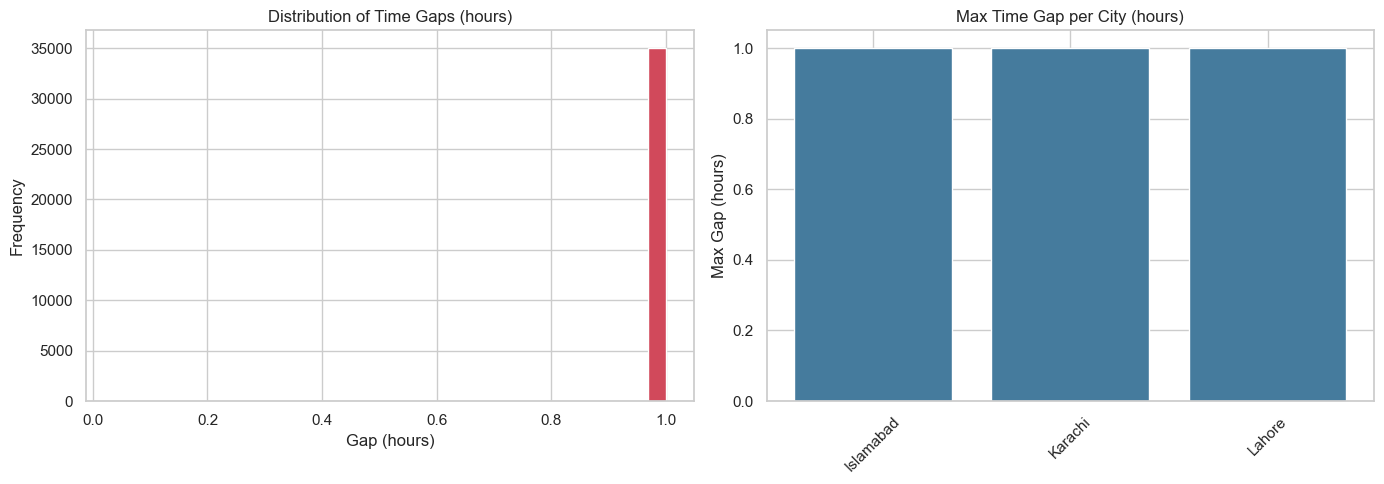

{'overall': {'expected_interval_minutes': 0,
  'max_gap_hours': 1.0,
  'num_gaps': 35021,
  'duplicate_timestamps': 70032},
 'per_city': {'Islamabad': {'expected_interval_minutes': 60,
   'max_gap_hours': 1.0,
   'num_gaps': 0,
   'duplicate_timestamps': 0},
  'Karachi': {'expected_interval_minutes': 60,
   'max_gap_hours': 1.0,
   'num_gaps': 0,
   'duplicate_timestamps': 0},
  'Lahore': {'expected_interval_minutes': 60,
   'max_gap_hours': 1.0,
   'num_gaps': 0,
   'duplicate_timestamps': 0}}}

In [16]:
# Check for missing timestamps and irregular intervals
all_timestamps = df_sorted[TIME_COL].sort_values()
time_diffs = all_timestamps.diff().dropna()

# Expected interval (most common)
expected_interval = time_diffs.mode()[0]
missing_timestamps = []
duplicate_timestamps = df_sorted[TIME_COL].duplicated().sum()

# Find gaps larger than expected interval
gaps = time_diffs[time_diffs > expected_interval * 1.5]

# For per-city gap analysis
city_gaps = {}
for city, group in df_sorted.groupby(CITY_COL):
    city_ts = group[TIME_COL].sort_values()
    city_diffs = city_ts.diff().dropna()
    city_gaps[city] = {
        "expected_interval_minutes": int(city_diffs.mode()[0].total_seconds() / 60) if len(city_diffs) > 0 else None,
        "max_gap_hours": round(city_diffs.max().total_seconds() / 3600, 2) if len(city_diffs) > 0 else None,
        "num_gaps": int((city_diffs > city_diffs.mode()[0] * 1.5).sum()) if len(city_diffs) > 0 else 0,
        "duplicate_timestamps": int(city_ts.duplicated().sum()),
    }

ts_stats["time_gap_analysis"] = {
    "overall": {
        "expected_interval_minutes": int(expected_interval.total_seconds() / 60),
        "max_gap_hours": round(gaps.max().total_seconds() / 3600, 2) if len(gaps) > 0 else 0,
        "num_gaps": len(gaps),
        "duplicate_timestamps": int(duplicate_timestamps),
    },
    "per_city": city_gaps,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gap distribution
if len(gaps) > 0:
    gap_hours = gaps.dt.total_seconds() / 3600
    axes[0].hist(gap_hours, bins=30, color="#d1495b", edgecolor="white")
    axes[0].set_title("Distribution of Time Gaps (hours)")
    axes[0].set_xlabel("Gap (hours)")
    axes[0].set_ylabel("Frequency")
else:
    axes[0].text(0.5, 0.5, "No significant gaps detected", ha="center", va="center", fontsize=12)
    axes[0].axis("off")

# Per-city max gap comparison
cities = list(city_gaps.keys())
max_gaps = [city_gaps[c]["max_gap_hours"] for c in cities]
axes[1].bar(cities, max_gaps, color="#457b9d")
axes[1].set_title("Max Time Gap per City (hours)")
axes[1].set_ylabel("Max Gap (hours)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "time_gap_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

ts_stats["time_gap_analysis"]

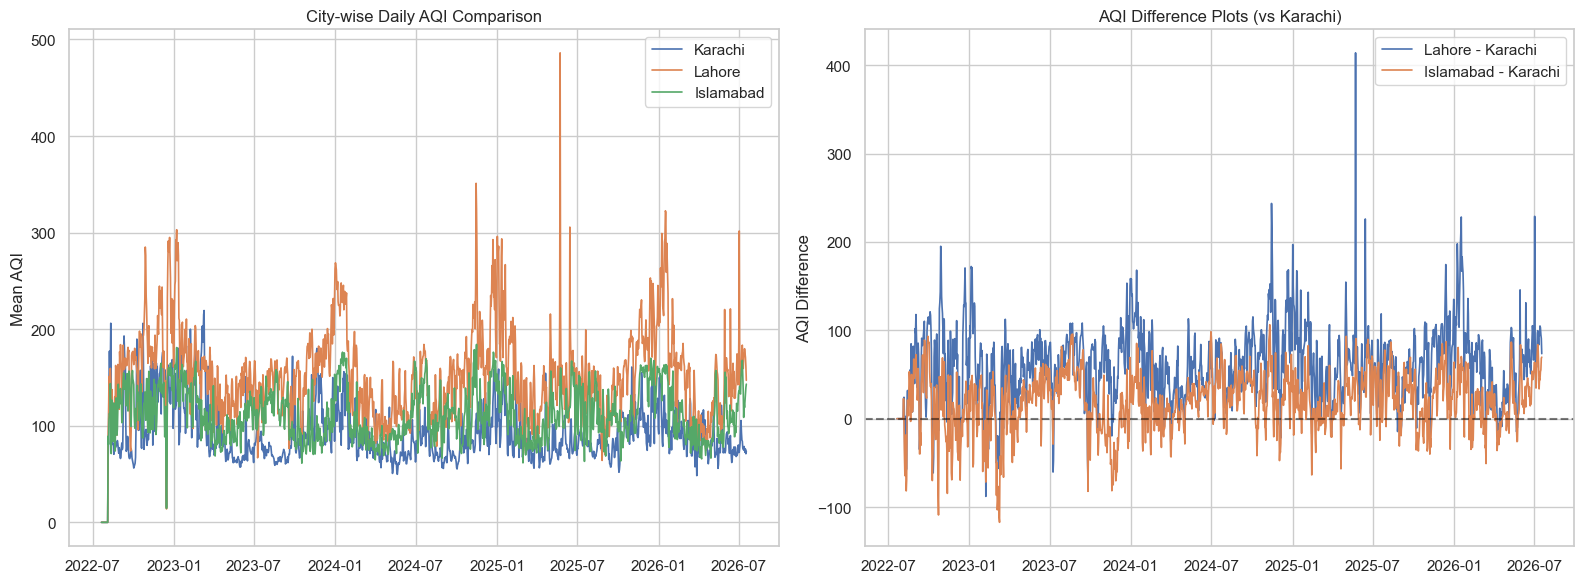

In [17]:
# Focus on major cities (adjust as per your dataset)
major_cities = ["Karachi", "Lahore", "Islamabad"]
available_major = [c for c in major_cities if c in df[CITY_COL].unique()]

if len(available_major) >= 2:
    city_daily = {}
    for city in available_major:
        city_data = df_sorted[df_sorted[CITY_COL] == city]
        city_daily[city] = city_data.set_index(TIME_COL)[TARGET_COL].resample("1D").mean()

    # Overlaid comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for city, series in city_daily.items():
        axes[0].plot(series.index, series.values, label=city, linewidth=1.2)
    axes[0].set_title("City-wise Daily AQI Comparison")
    axes[0].set_ylabel("Mean AQI")
    axes[0].legend()

    # Difference plot (first city as reference)
    ref_city = available_major[0]
    for city in available_major[1:]:
        common_index = city_daily[ref_city].index.intersection(city_daily[city].index)
        diff = city_daily[city].reindex(common_index) - city_daily[ref_city].reindex(common_index)
        axes[1].plot(diff.index, diff.values, label=f"{city} - {ref_city}", linewidth=1.2)
    axes[1].axhline(y=0, color="black", linestyle="--", alpha=0.5)
    axes[1].set_title(f"AQI Difference Plots (vs {ref_city})")
    axes[1].set_ylabel("AQI Difference")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "city_wise_timeseries_comparison.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("Need at least 2 of Karachi/Lahore/Islamabad for comparison.")

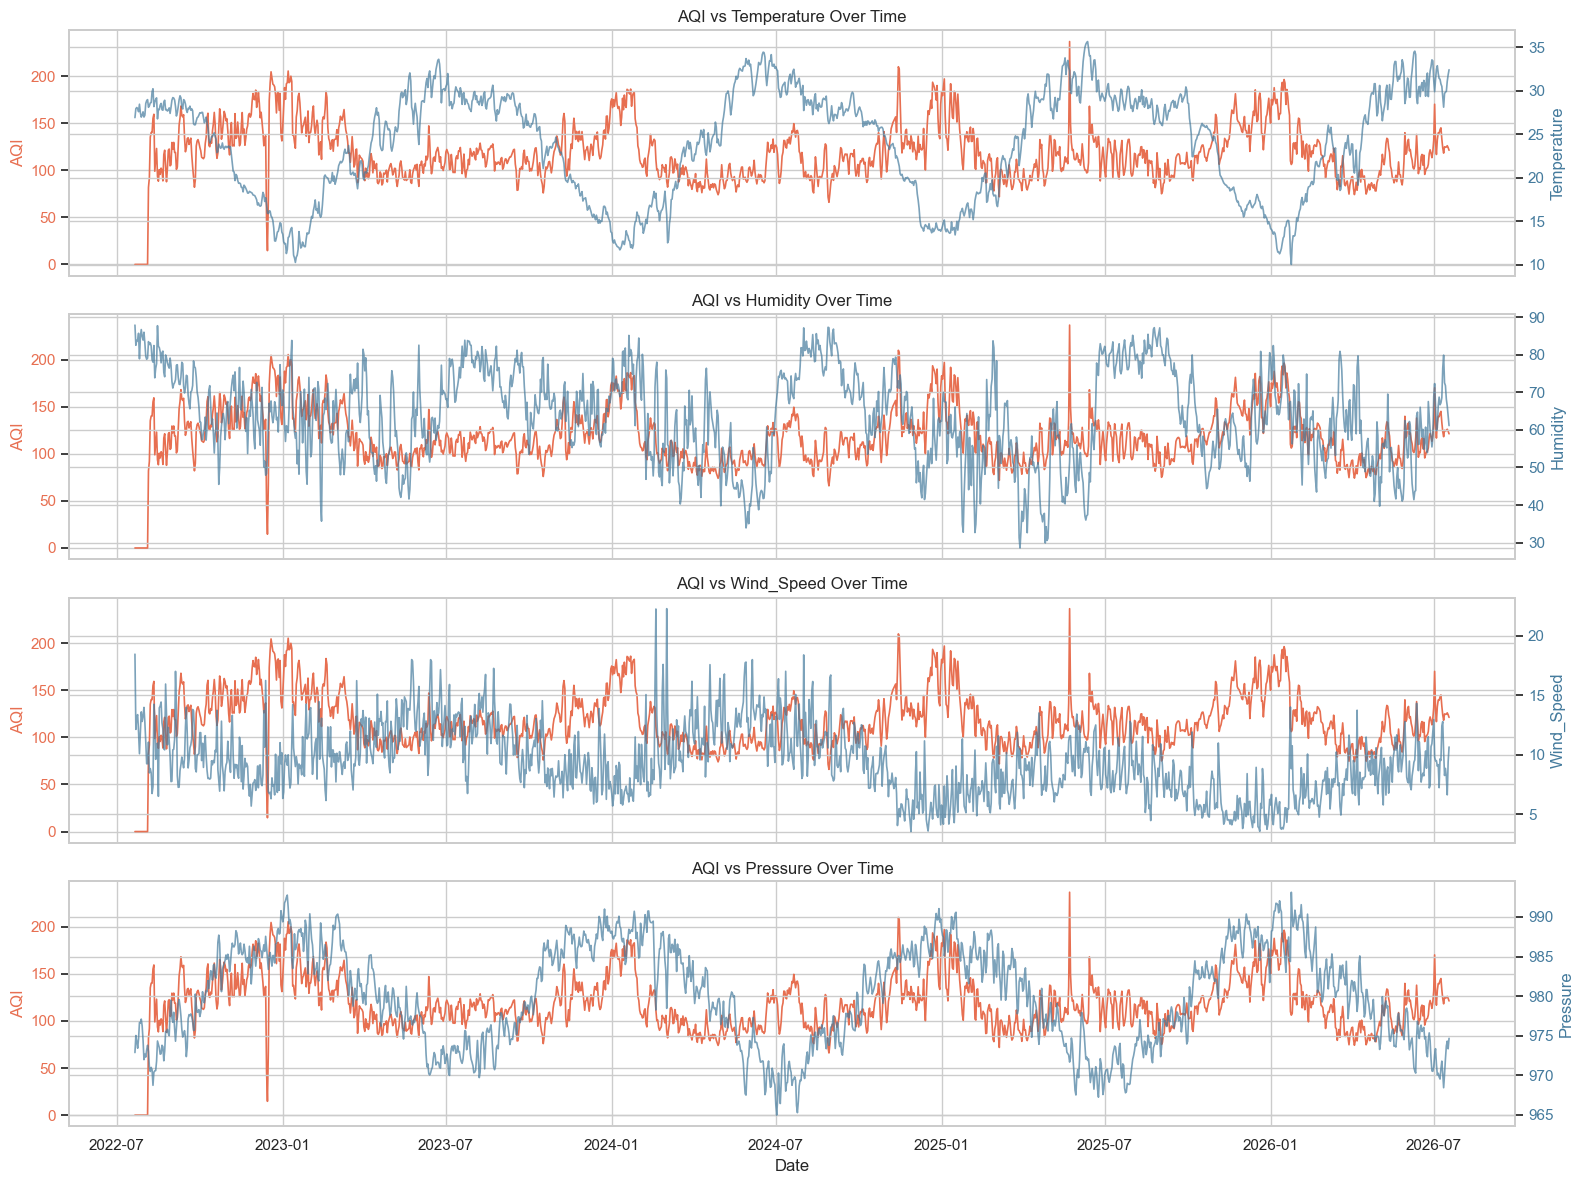

In [18]:
weather_vs_aqi = [c for c in ["temperature", "humidity", "wind_speed", "pressure"] if c in df.columns]

fig, axes = plt.subplots(len(weather_vs_aqi), 1, figsize=(16, 3 * len(weather_vs_aqi)), sharex=True)
if len(weather_vs_aqi) == 1:
    axes = [axes]

for i, col in enumerate(weather_vs_aqi):
    # Resample both to daily
    daily_aqi = df_sorted.set_index(TIME_COL)[TARGET_COL].resample("1D").mean()
    daily_weather = df_sorted.set_index(TIME_COL)[col].resample("1D").mean()
    common_idx = daily_aqi.index.intersection(daily_weather.index)

    ax_twin = axes[i].twinx()
    axes[i].plot(common_idx, daily_aqi.reindex(common_idx), color="#e76f51", label="AQI", linewidth=1.2)
    ax_twin.plot(common_idx, daily_weather.reindex(common_idx), color="#457b9d", label=col.title(), linewidth=1.2, alpha=0.7)

    axes[i].set_ylabel("AQI", color="#e76f51")
    ax_twin.set_ylabel(col.title(), color="#457b9d")
    axes[i].set_title(f"AQI vs {col.title()} Over Time")
    axes[i].tick_params(axis="y", labelcolor="#e76f51")
    ax_twin.tick_params(axis="y", labelcolor="#457b9d")

axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "weather_vs_aqi_through_time.png", dpi=110, bbox_inches="tight")
plt.show()

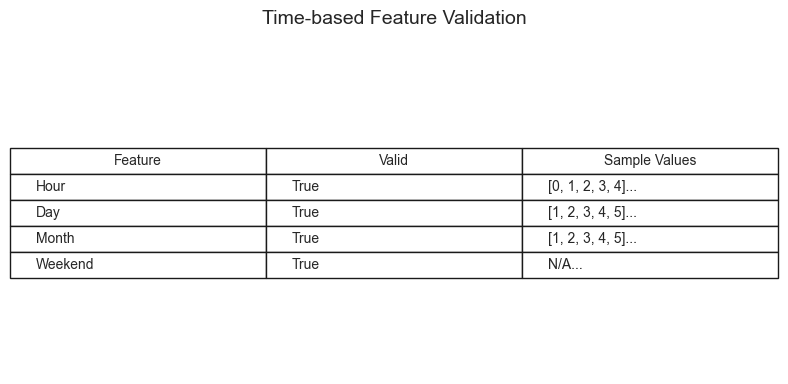

{'hour': {'matches_derived': True,
  'unique_values': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23]},
 'day': {'matches_derived': True,
  'unique_values': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31]},
 'month': {'matches_derived': True,
  'unique_values': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]},
 'weekend': {'matches_derived': True, 'value_counts': {0: 75024, 1: 30030}}}

In [20]:
validation_results = {}

# Hour feature validation
if "hour" in df.columns:
    derived_hour = df[TIME_COL].dt.hour
    hour_match = (df["hour"] == derived_hour).all()
    validation_results["hour"] = {"matches_derived": bool(hour_match), "unique_values": sorted(df["hour"].unique().tolist())}

# Day feature validation
if "day" in df.columns:
    derived_day = df[TIME_COL].dt.day
    day_match = (df["day"] == derived_day).all()
    validation_results["day"] = {"matches_derived": bool(day_match), "unique_values": sorted(df["day"].unique().tolist())}

# Month feature validation
if "month" in df.columns:
    derived_month = df[TIME_COL].dt.month
    month_match = (df["month"] == derived_month).all()
    validation_results["month"] = {"matches_derived": bool(month_match), "unique_values": sorted(df["month"].unique().tolist())}

# Weekend feature validation
if "is_weekend" in df.columns:
    derived_weekend = df[TIME_COL].dt.dayofweek.isin([5, 6]).astype(int)
    weekend_match = (df["is_weekend"] == derived_weekend).all()
    validation_results["weekend"] = {"matches_derived": bool(weekend_match), "value_counts": df["is_weekend"].value_counts().to_dict()}

ts_stats["feature_validation"] = validation_results

# Visual validation summary
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table_data = [[k.replace("_", " ").title(), str(v["matches_derived"]), str(v.get("unique_values", "N/A")[:5]) + "..."] for k, v in validation_results.items()]
table = ax.table(cellText=table_data, colLabels=["Feature", "Valid", "Sample Values"], loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title("Time-based Feature Validation", fontsize=14, pad=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_validation.png", dpi=110, bbox_inches="tight")
plt.show()

validation_results

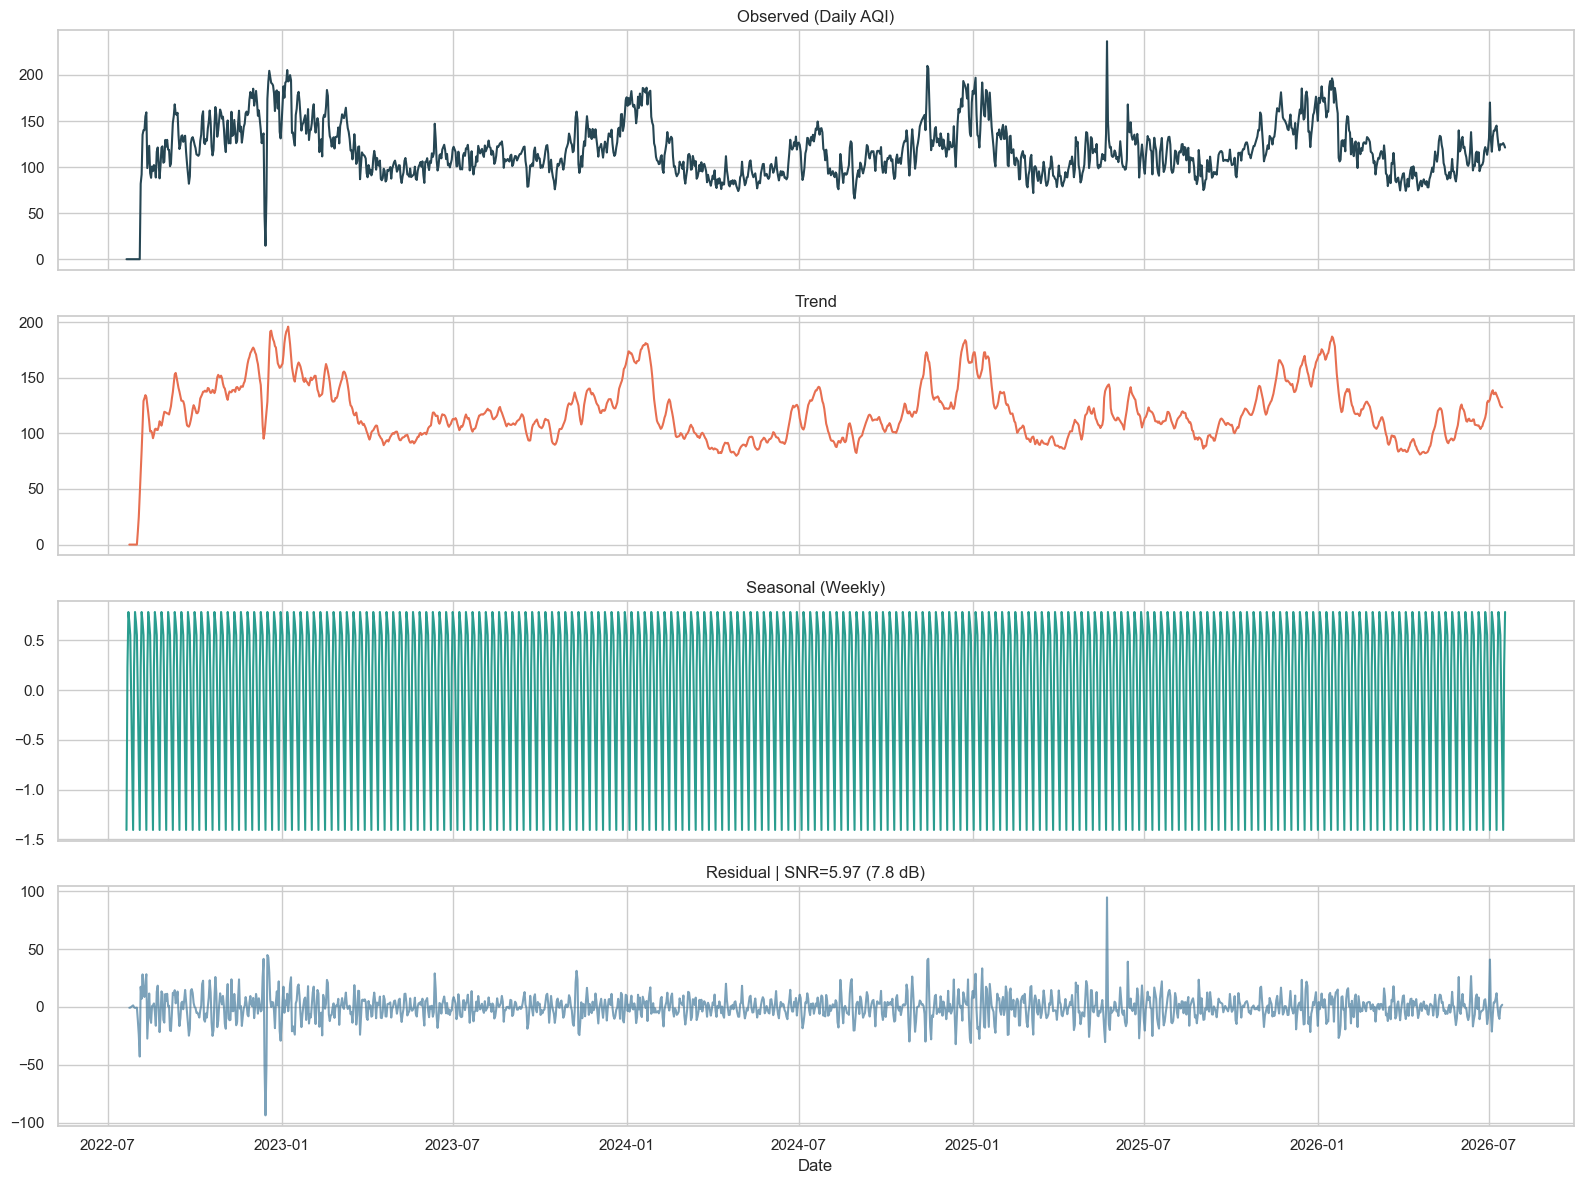

SNR: 5.97 (7.8 dB)
Trend Std: 26.33 | Seasonal Std: 0.75 | Residual Std: 10.78


In [21]:
# Seasonal decomposition (daily frequency, weekly seasonality)
decomposition = seasonal_decompose(daily_aqi.dropna(), model="additive", period=7)

trend = decomposition.trend
trend_std = trend.dropna().std()
seasonal = decomposition.seasonal
seasonal_std = seasonal.dropna().std()
residual = decomposition.resid
residual_std = residual.dropna().std()

# Signal-to-Noise Ratio
signal_power = trend_std**2 + seasonal_std**2
noise_power = residual_std**2
snr = signal_power / noise_power if noise_power > 0 else np.inf
snr_db = 10 * np.log10(snr) if snr != np.inf else np.inf

ts_stats["forecastability"] = {
    "trend_std": round(float(trend_std), 4),
    "seasonal_std": round(float(seasonal_std), 4),
    "residual_std": round(float(residual_std), 4),
    "signal_to_noise_ratio": round(float(snr), 4),
    "snr_db": round(float(snr_db), 4) if snr_db != np.inf else "inf",
    "noise_level_estimate": round(float(residual_std), 4),
}

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
axes[0].plot(decomposition.observed.index, decomposition.observed.values, color="#264653")
axes[0].set_title("Observed (Daily AQI)")
axes[1].plot(trend.index, trend.values, color="#e76f51")
axes[1].set_title("Trend")
axes[2].plot(seasonal.index, seasonal.values, color="#2a9d8f")
axes[2].set_title("Seasonal (Weekly)")
axes[3].plot(residual.index, residual.values, color="#457b9d", alpha=0.7)
axes[3].set_title(f"Residual | SNR={snr:.2f} ({snr_db:.1f} dB)")
axes[3].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "seasonal_decomposition.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"SNR: {snr:.2f} ({snr_db:.1f} dB)")
print(f"Trend Std: {trend_std:.2f} | Seasonal Std: {seasonal_std:.2f} | Residual Std: {residual_std:.2f}")

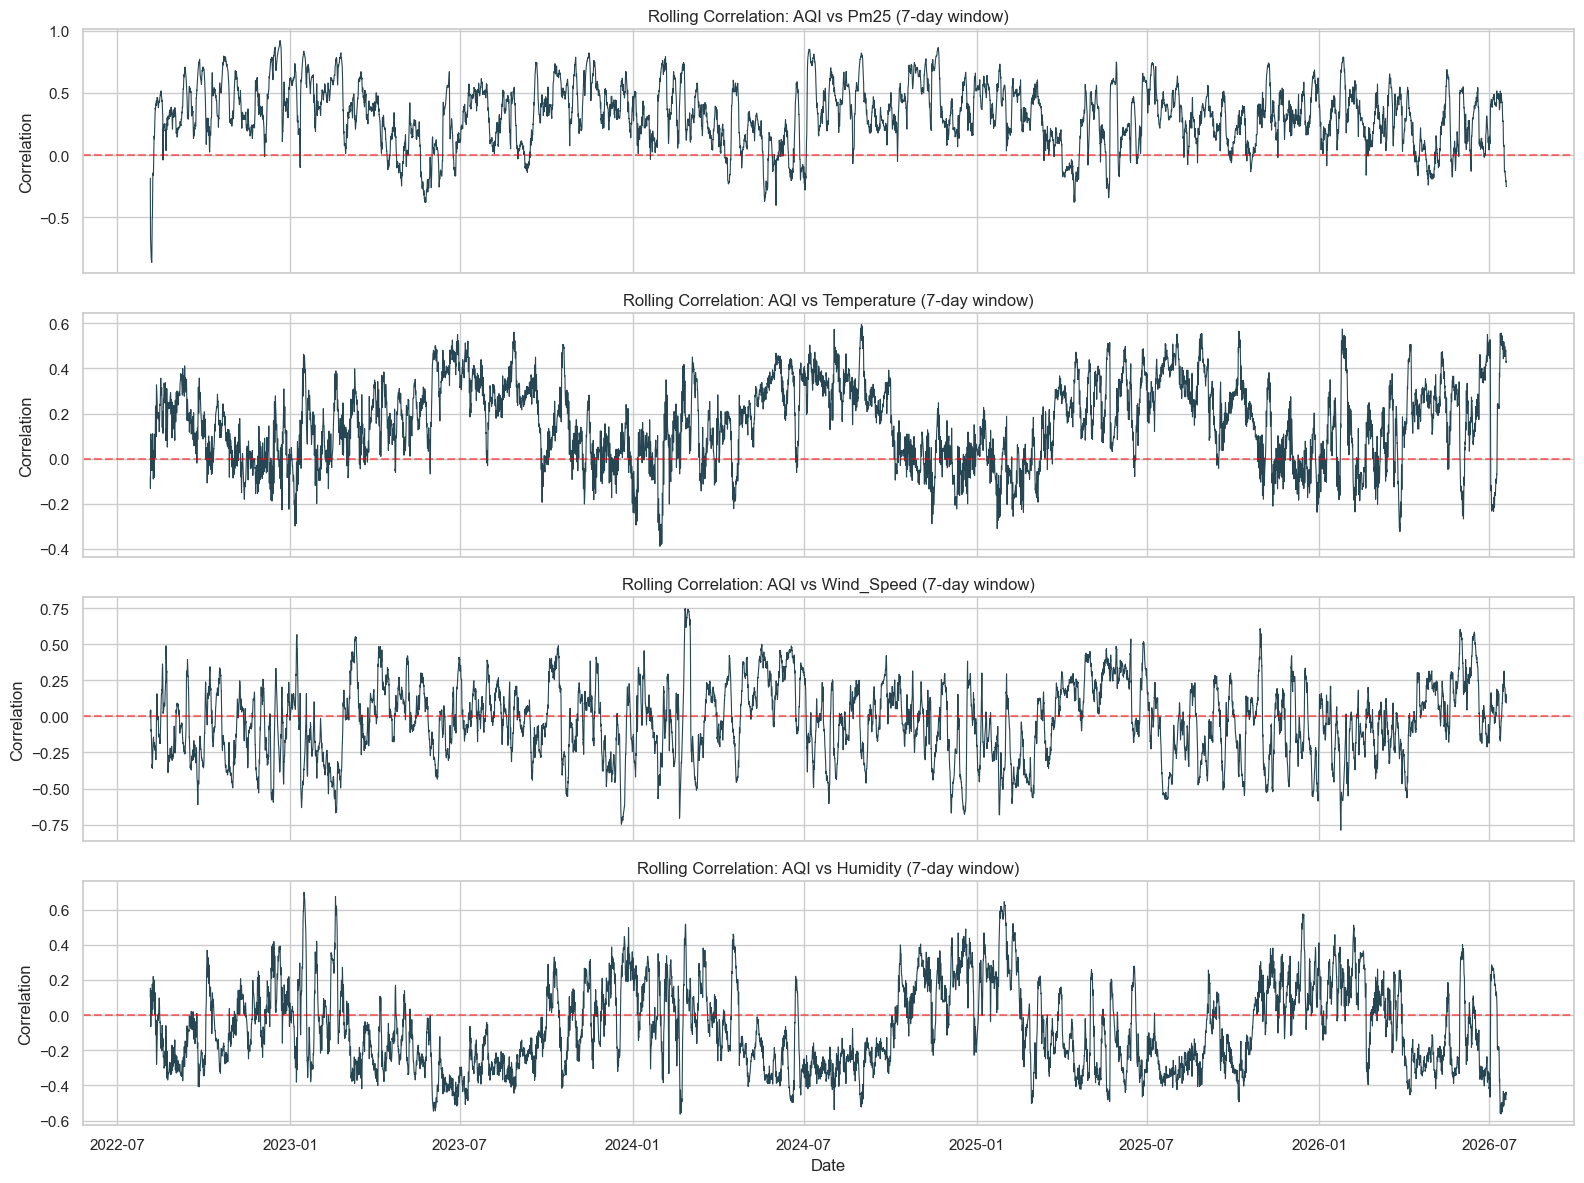

{'pm25': {'mean': 0.3226, 'std': 0.2413, 'min': -0.8637, 'max': 0.9225},
 'temperature': {'mean': 0.16, 'std': 0.1763, 'min': -0.3886, 'max': 0.5952},
 'wind_speed': {'mean': -0.031, 'std': 0.2565, 'min': -0.7888, 'max': 0.7483},
 'humidity': {'mean': -0.077, 'std': 0.2361, 'min': -0.5635, 'max': 0.6988}}

In [23]:
rolling_corr_vars = ["pm25", "temperature", "wind_speed", "humidity"]
rolling_corr_vars = [c for c in rolling_corr_vars if c in df.columns]

window = 168  # 7 days in hours

# ── FIX: Sirf numeric columns resample karo ────────────────────────
numeric_cols_for_resample = [TARGET_COL] + rolling_corr_vars
hourly_df = (
    df_sorted.set_index(TIME_COL)[numeric_cols_for_resample]
    .resample("1H")
    .mean()
    .interpolate(method="linear")
)

fig, axes = plt.subplots(len(rolling_corr_vars), 1, figsize=(16, 3 * len(rolling_corr_vars)), sharex=True)
if len(rolling_corr_vars) == 1:
    axes = [axes]

rolling_corr_stats = {}
for i, col in enumerate(rolling_corr_vars):
    roll_corr = hourly_df[TARGET_COL].rolling(window=window).corr(hourly_df[col])
    rolling_corr_stats[col] = {
        "mean": round(float(roll_corr.mean()), 4),
        "std": round(float(roll_corr.std()), 4),
        "min": round(float(roll_corr.min()), 4),
        "max": round(float(roll_corr.max()), 4),
    }
    axes[i].plot(roll_corr.index, roll_corr.values, color="#264653", linewidth=0.8)
    axes[i].axhline(y=0, color="red", linestyle="--", alpha=0.5)
    axes[i].set_title(f"Rolling Correlation: AQI vs {col.title()} (7-day window)")
    axes[i].set_ylabel("Correlation")

axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rolling_correlation.png", dpi=110, bbox_inches="tight")
plt.show()

ts_stats["rolling_correlation"] = rolling_corr_stats
rolling_corr_stats

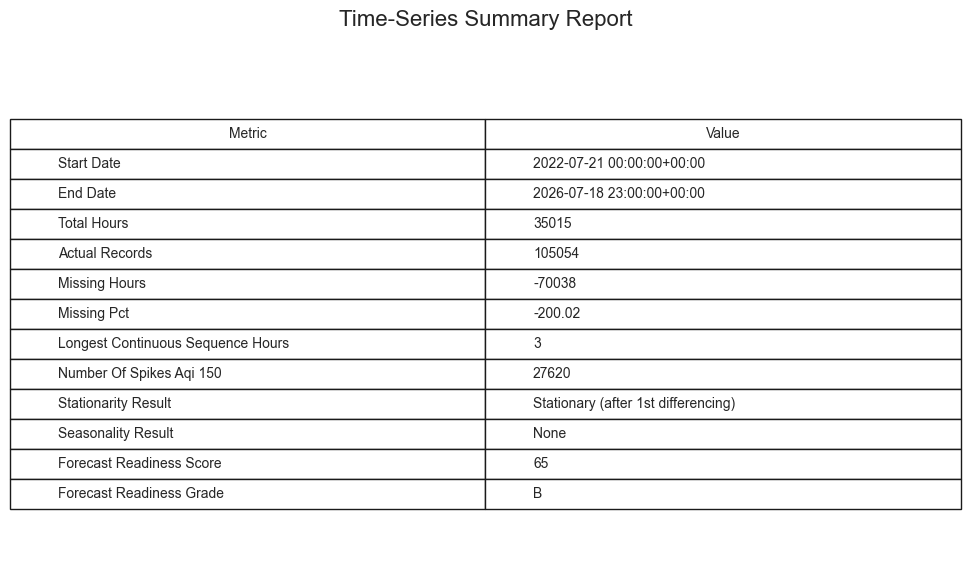

{'start_date': '2022-07-21 00:00:00+00:00',
 'end_date': '2026-07-18 23:00:00+00:00',
 'total_hours': 35015,
 'actual_records': 105054,
 'missing_hours': -70038,
 'missing_pct': -200.02,
 'longest_continuous_sequence_hours': 3,
 'number_of_spikes_aqi_150': 27620,
 'stationarity_result': 'Stationary (after 1st differencing)',
 'seasonality_result': 'None',
 'forecast_readiness_score': 65,
 'forecast_readiness_grade': 'B'}

In [24]:
start_date = df[TIME_COL].min()
end_date = df[TIME_COL].max()
total_hours = int((end_date - start_date).total_seconds() / 3600)

# Expected vs actual records
expected_records = total_hours + 1
actual_records = len(df)
missing_hours = expected_records - actual_records

# Longest continuous sequence (no gaps > 1.5x expected interval)
continuous_sequences = []
current_seq = 1
for diff in time_diffs:
    if diff <= expected_interval * 1.5:
        current_seq += 1
    else:
        continuous_sequences.append(current_seq)
        current_seq = 1
continuous_sequences.append(current_seq)

# Number of spikes (AQI > 150)
num_spikes = int((aqi_series > 150).sum())

# Stationarity result
stationarity_result = "Stationary" if adf_raw["is_stationary"] and kpss_raw["is_stationary"] else "Non-Stationary"
if adf_diff["is_stationary"] and kpss_diff["is_stationary"]:
    stationarity_result += " (after 1st differencing)"

# Seasonality result
seasonality_result = "Strong" if seasonal_std > residual_std else "Weak" if seasonal_std > residual_std * 0.5 else "None"

# Forecast readiness score (0-100)
score = 0
score += 20 if adf_diff["is_stationary"] else 5
score += 20 if seasonal_std > residual_std * 0.3 else 5
score += 15 if snr > 1 else 5
score += 15 if missing_hours / total_hours < 0.05 else 5
score += 15 if max(continuous_sequences) > 168 else 5
score += 15 if num_spikes < len(df) * 0.1 else 5

ts_summary = {
    "start_date": str(start_date),
    "end_date": str(end_date),
    "total_hours": total_hours,
    "actual_records": actual_records,
    "missing_hours": missing_hours,
    "missing_pct": round(missing_hours / total_hours * 100, 2),
    "longest_continuous_sequence_hours": int(max(continuous_sequences)),
    "number_of_spikes_aqi_150": num_spikes,
    "stationarity_result": stationarity_result,
    "seasonality_result": seasonality_result,
    "forecast_readiness_score": score,
    "forecast_readiness_grade": "A" if score >= 80 else "B" if score >= 60 else "C" if score >= 40 else "D",
}

ts_stats["timeseries_summary"] = ts_summary

# Visual summary
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
table_data = [[k.replace("_", " ").title(), str(v)] for k, v in ts_summary.items()]
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"], loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.6)
ax.set_title("Time-Series Summary Report", fontsize=16, pad=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "timeseries_summary_report.png", dpi=110, bbox_inches="tight")
plt.show()

ts_summary

In [25]:
with STATS_PATH.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "dataset_path": str(DATA_PATH),
            "shape": {"rows": df.shape[0], "columns": df.shape[1]},
            **ts_stats,
        },
        f,
        indent=2,
        default=str,
    )

print(f"Time-Series Stats saved -> {STATS_PATH}")

Time-Series Stats saved -> ..\reports\eda_timeseries\timeseries_stats.json
